# Security-Constrained LOPF

In this example, the dispatch of generators is optimized using the securitu-constrained linear optimal power flow (SCLOPF) functionality of PyPSA, to guarantee that no branches are overloaded in the event of certain branch outages.

### Learning Content:

Normal optimal power flow ensures: $|F_l| \leq F_l^{max} $

Security-constrained optimal pwoer flow ensures: $|F_l^{(k)}| \leq F_l^{max} $ for all contingencies $k$.

Where:
* $k=$ failure of a line (N-1) contingency
* $F_l^{(k)} =$ flow on the line $l$ after outage $k$

THis enforces the $N-1$ security criterion

#### 1. What is $N-1$ Security?

The grid must survive the loss of:
* Any one transmission line
* Any one generator
* Any one transformer

Formally: System remains feasible after loss of any single component.

This is how real TSOs operate.

#### 2. Mathematical Structure of SCOPF:

We now have two layers:

**Base Case Constraints:**
$$ F_l^{(0)} = B_l (\theta_i - \theta_j) $$
$$ |F_l^{(0)}| \leq F_l^{(max)} $$

**Contingency Constraints:**

For each outage $k$: $$ |F_l^{(k)}| \leq F_l^{max} $$
So the optimization must satify many parallel network states. If there are $L$ lines and $T$ time steps, then constraints scale roughly $ O(L^2 \cdot T)$. This is why SCOPF becomes computationally heavy.

#### 3. How flows change after a line line outage:
The key idea is: when line $k$ fails,
* Power redistributes over the remaining network.
* Flows change _linearly_ under DC assumptions.

This uses: **Line Outage Distribution Factors**
$$ F_l^{(k)} = F_l + LODF_{l,k} \cdot F_k $$
Where:
* $F_k=$ flow on failed line before outage
* $LODF_{l,k}=$ sensitivity factor

This avoids solving a new power flow for each contingency. 

#### 4. What is done below:
Conceptually:

### Code

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


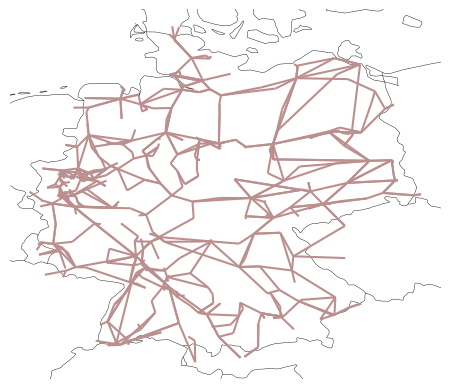

In [3]:
import pypsa

n = pypsa.examples.scigrid_de()

# correct some infeasibilities in the network
for line_name in ["316", "527", "602"]:
    n.lines.loc[line_name, "s_nom"] = 1200

now = n.snapshots[0]

n.plot(bus_size=0);

First, let's run the network without any $N-1$ security constraints and see how much it costs to operate the system:

In [4]:
n0 = n.copy()
n0.optimize(snapshots=now)
n0.statistics.opex().sum()

Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '232',
       '233', '236', '247', '248', '250', '251', '252', '261', '263', '264',
       '267', '272', '279', '281', '282', '292', '303', '307', '308', '312',
       '315', '317', '322', '332', '334', '336', '338', '351', '353', '360',
       '362', '382', '384', '385', '391', '403', '404', '413', '421', '450',
       '458'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 2.82s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2485 primals, 5957 duals
Objective: 3.32e+05
Solver model: avail

Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-aw51se65 has 5957 rows; 2485 cols; 10851 nonzeros
Coefficient ranges:
  Matrix  [1e-02, 2e+02]
  Cost    [3e+00, 1e+02]
  Bound   [0e+00, 0e+00]
  RHS     [1e-07, 7e+03]
Presolving model
758 rows, 1653 cols, 4440 nonzeros  0s
569 rows, 1462 cols, 4153 nonzeros  0s
Dependent equations search running on 510 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
510 rows, 1253 cols, 3913 nonzeros  0s
Presolve reductions: rows 510(-5447); columns 1253(-1232); nonzeros 3913(-6938) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
        584     3.3238351399e+05 Pr: 0(0); Du: 0(8.88178e-16) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy

np.float64(332383.51399999997)

The security-constrained LOPF is executed using the ```n.optimize.optimize_security_constrained()``` method. This method takes a list of snapshots (here: ```now```) and a list of branches that are to be considered as outages (here, the 30 lines with the highest loading).

In [5]:
branch_outages = (n0.lines_t.p0.loc[now] / n0.lines.s_nom).nlargest(30).index
n.optimize.optimize_security_constrained(now, branch_outages = branch_outages, log_to_console=False)
n.statistics.opex().sum()

Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '232',
       '233', '236', '247', '248', '250', '251', '252', '261', '263', '264',
       '267', '272', '279', '281', '282', '292', '303', '307', '308', '312',
       '315', '317', '322', '332', '334', '336', '338', '351', '353', '360',
       '362', '382', '384', '385', '391', '403', '404', '413', '421', '450',
       '458'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2485 

np.float64(424597.83679)

You can see that the cost of operating the system in the given hour rises from 332 k€ to 427 k€ when the security constraints are applied.

The maps below indicate the difference in the dispatch patterns, line flows and marginal prices between the $N-0$ (first) and $N-1$ (second) cases.

In [6]:
def plot_network(n,snapshot):
   bus_size = (
      n.statistics.supply(groupby="bus", components=["Generator", "StorageUnit"]).groupby("bus").sum()
   )
   line_flows = n.lines_t.p0.loc[snapshot]
   bus_color = n.buses_t.marginal_price.loc[snapshot]
   line_loading = n.lines_t.p0.abs().loc[snapshot] / n.lines.s_nom

   n.plot(
      bus_size = bus_size / 30000,
      bus_color = bus_color,
      bus_cmap = "Reds",
      line_color = line_loading,
      line_flow = line_flows / 50
   )

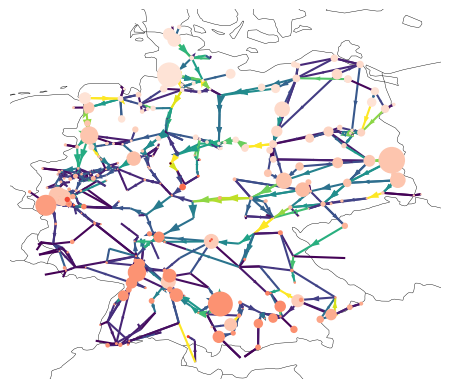

In [7]:
plot_network(n0, now)

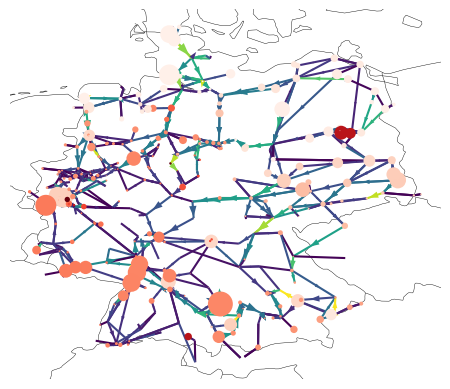

In [8]:
plot_network(n, now)

We can look at where the nodal dispatch is ramped up (red) or down (blue) in the $N-1$ case compared to the $N-0$ case. Mostly this means ramp down upstream of the potentialoutages, and ramp up downstream of the potential outages.

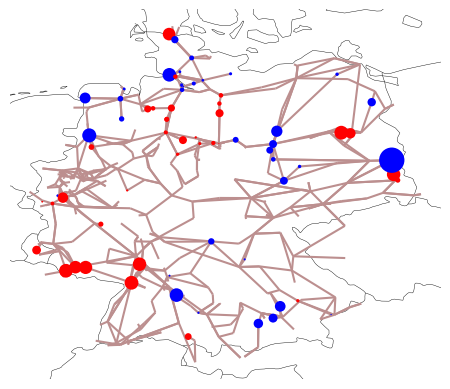

In [9]:
bus_size0 = (
    (
        n0.statistics.supply(groupby="bus", components=["Generator", "StorageUnit"]).groupby("bus").sum()
    )
    .reindex(index=n.buses.index)
    .fillna(0)  
)

bus_size1 = (
    (
        n.statistics.supply(groupby="bus", components=["Generator", "StorageUnit"]).groupby("bus").sum()
    )
    .reindex(index=n.buses.index)
    .fillna(0)  
)

bus_size = bus_size1 - bus_size0

n.plot(
    bus_size = bus_size.abs() / 30000,
    bus_color = bus_size.map(lambda x : "b" if x < 0 else "r"),
);

We can also double-check that the $N-1$ constraints are satisfied and no lines are overloaded in the event of the outages considered:

In [10]:
n.optimize.fix_optimal_dispatch()
p0_test = n.lpf_contingency(now, branch_outages = branch_outages)

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x7370e47c4c80> for snapshot(s) DatetimeIndex(['2011-01-01'], dtype='datetime64[ns]', name='snapshot', freq=None)


Check the maximum loading as per unit of ```s_nom``` in each contingency:

In [12]:
max_loading = abs(p0_test.divide(n.passive_branches().s_nom, axis=0)).max()
max_loading

base           1.0
(Line, 183)    1.0
(Line, 214)    1.0
(Line, 350)    1.0
(Line, 389)    1.0
(Line, 448)    1.0
(Line, 586)    1.0
(Line, 608)    1.0
(Line, 809)    1.0
(Line, 390)    1.0
(Line, 587)    1.0
(Line, 707)    1.0
(Line, 818)    1.0
(Line, 124)    0.0
(Line, 682)    1.0
(Line, 683)    1.0
(Line, 29)     1.0
(Line, 218)    1.0
(Line, 714)    1.0
(Line, 595)    1.0
(Line, 596)    1.0
(Line, 371)    1.0
(Line, 17)     1.0
(Line, 514)    1.0
(Line, 511)    1.0
(Line, 510)    1.0
(Line, 58)     1.0
(Line, 254)    1.0
(Line, 792)    1.0
(Line, 436)    1.0
(Line, 11)     1.0
dtype: float64